In [1]:
import numpy as np

import json
from matplotlib import pyplot as plt 
from pathlib import Path

from matplotlib import cm
import pandas as pd

In [2]:
# # DATA_DIR = Path("../../tmp/toy-experiments-5k")
# # # DATA_DIR = Path("../../artifacts/2023-05-s6/dev/toy-experiments")
# # DATA_DIR = Path("../../artifacts/2023-05-s6/toy-experiments")
# # DATA_DIR = Path("../../artifacts/2023-06-s7/dev/toy-experiments-gaussian-blobs-ellip")
# toy-experiments/gaussian-blobs/toy-dataset-
DATA_DIR = Path("../../artifacts/2023-06-s8/toy-experiments/gaussian-blobs")

# DATA_DIR = Path("../../artifacts/2023-06-s8/toy-experiments/gaussian-blobs-nc10")

# Accuracy and AUROC Analysis Across Noise

In [3]:
def load_meta(
    model,
    seed, 
    eps,
    covdiag
):
        
    filepath = DATA_DIR / f"toy-dataset-eps{eps}-covdiag{covdiag}-seed{seed}" / model / "meta.json"
    
    with open(filepath) as fh:
        return json.load(fh)
    
load_meta("mlp16", seed=1, eps=0.5, covdiag=False)

{'accuracy': 0.09780000150203705,
 'aurocs': {'mlp-auroc-p0': 0.7018518447875977,
  'mlp-auroc-p1': 0.6727403998374939,
  'mlp-auroc-p2': 0.6760537326335907,
  'mlp-auroc-p4947': 1.0,
  'mlp-auroc-p4948': 1.0,
  'mlp-auroc-p4949': 1.0,
  'mlp-binacc-p0': 0.6240000128746033,
  'mlp-binacc-p1': 0.5980392098426819,
  'mlp-binacc-p2': 0.6363636255264282,
  'mlp-binacc-p4947': 1.0,
  'mlp-binacc-p4948': 0.9951691031455994,
  'mlp-binacc-p4949': 1.0,
  'qda-auroc-p0': 0.7475213408470154,
  'qda-auroc-p1': 0.669447124004364,
  'qda-auroc-p2': 0.6991322338581085,
  'qda-auroc-p4947': 1.0,
  'qda-auroc-p4948': 1.0,
  'qda-auroc-p4949': 1.0,
  'qda-binacc-p0': 0.6480000019073486,
  'qda-binacc-p1': 0.6151960492134094,
  'qda-binacc-p2': 0.6477272510528564,
  'qda-binacc-p4947': 1.0,
  'qda-binacc-p4948': 1.0,
  'qda-binacc-p4949': 1.0},
 'basis_names': 'pca,prca-abs',
 'cov_diag': False,
 'epochs': 100,
 'eps': 0.5,
 'mode': 'centered',
 'model': 'mlp16',
 'output_dir': './artifacts/2023-06-s8/t

# AUROC for Compression

In [4]:
def load_auroc(eps, seeds, subset_slug, basis_name, model, layer, covdiag):
    
    merged_key = "auroc"
    
    
    merged_stat = dict()
    
    arr_aurocs = []
    arr_area_aurocs = []
    arr_teacher_aurocs = []
    
    for six, seed in enumerate(seeds):
        
        file = DATA_DIR / f"toy-dataset-eps{eps}-covdiag{covdiag}-seed{seed}" / model / f"subdataset--{subset_slug}" / layer / basis_name / "auroc.json"


        with open(file, "r") as fh:
            _stat = json.load(fh)
                        
        ks = np.array(_stat["ks"])
        if six == 0:
            merged_stat["ks"] = ks
        else:
            assert (merged_stat["ks"] == ks).all()
        
        auroc = np.array(_stat["auroc"])
        auroc = np.where(auroc < 0.5, 1-auroc, auroc)
        
        
        assert ks[0] == 0
        
        # ks = [0, 1, ..., d]
        # auroc: shape = (num ks,)
        area_auroc_varying_k = np.trapz(
            auroc,
            dx=1/ks[-1]
        )
        
        
        arr_aurocs.append(auroc)
        arr_area_aurocs.append(area_auroc_varying_k)
        arr_teacher_aurocs.append(auroc[-1])
        
    # shape: (num_seeds, len(ks))
    arr_aurocs = np.vstack(arr_aurocs)
    
    nseeds = len(seeds)
    assert arr_aurocs.shape[0] ==  nseeds
    
    merged_stat["mean_auroc"] = np.mean(arr_aurocs, axis=0)
    merged_stat["stderr_auroc"] = np.std(arr_aurocs, axis=0) / (nseeds ** 0.5)
    
    
    merged_stat["mean_area_auroc"] = np.mean(arr_area_aurocs, axis=0)
    merged_stat["stderr_area_auroc"] = np.std(arr_area_aurocs, axis=0) / (nseeds ** 0.5)
    
    
    merged_stat['mean_teacher_auroc'] = np.mean(arr_teacher_aurocs)
    merged_stat['std_teacher_auroc'] = np.std(arr_teacher_aurocs) / (nseeds ** 0.5)

    return merged_stat

    
load_auroc(
    eps=0.5, seeds=range(1, 1+1), 
    subset_slug="p0", 
    model="mlp16", basis_name="pca--centered", 
    layer="act2",
    covdiag=False
)

{'ks': array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 'mean_auroc': array([0.5       , 0.62595439, 0.62635326, 0.67965814, 0.70891738,
        0.70358974, 0.7029345 , 0.70185184, 0.70185184]),
 'stderr_auroc': array([0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'mean_area_auroc': 0.6687731482088566,
 'stderr_area_auroc': 0.0,
 'mean_teacher_auroc': 0.7018518447875977,
 'std_teacher_auroc': 0.0}

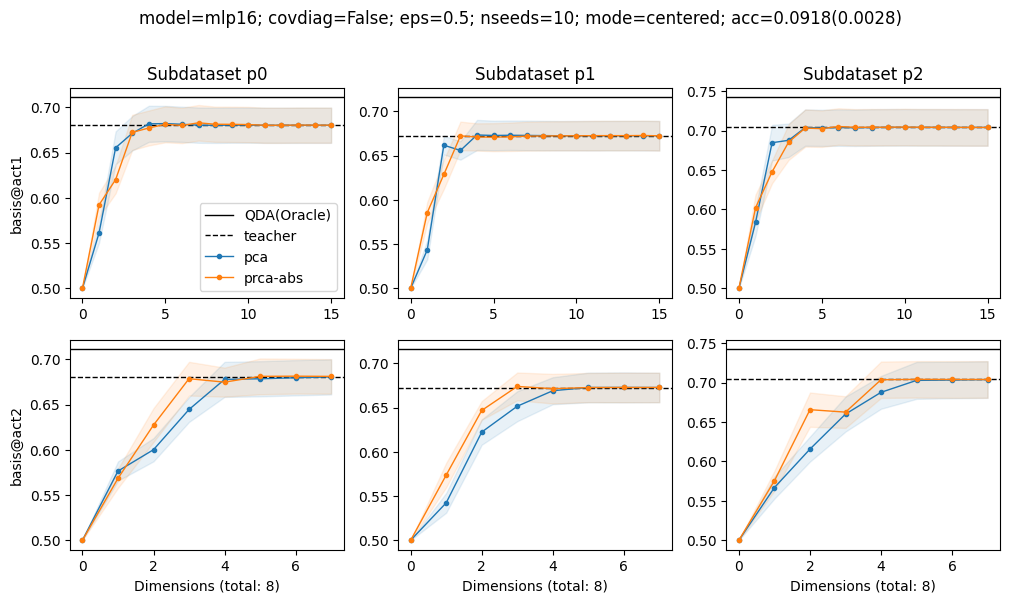

In [5]:
def color(name):
    if "random" in name:
        return "lightgray"
    elif "prca-reconreg" in name:
        beta = name.split("reg")[-1]
        color_norm = dict(zip(
            ["0.0", "0.1", "1.0", "10.0"][1:],
            [0.3, 0.5, 0.75, 0.8][:3]
        ))
        return cm.Greys(color_norm[beta])
    else:
        return None
def ls(name):
    if "prca" == name:
        return "--"
    else:
        return None
    
def viz_auroc(
    model="mlp16", eps=1.0, 
    seeds=list(range(1, 10+1)), 
    layers=[
        "act1",
        "act2"
    ],
    basis_names = [
        "pca", "prca-abs", 
#         "prca-recon",
#         "prca",
#         "random1", "random2", "random3",
    ],
    mode="centered",
    pairs=["p0", "p1", "p2"],
    covdiag=False
):
    
    
    nrows = len(layers)
    ncols = 3
    plt.figure(figsize=(ncols*4, nrows*3))
    
    arr_accs = []    
    for seed in seeds:
        meta = load_meta(model, seed=seed, eps=eps, covdiag=covdiag)
        arr_accs.append(meta["accuracy"])

    mean_acc, std_acc = np.mean(arr_accs), np.std(arr_accs)
    
    plt.suptitle(
        f"model={model}; covdiag={covdiag}; eps={eps}; nseeds={len(seeds)}; mode={mode}; acc={mean_acc:.4f}({std_acc:.4f})",
        y=1.01
    )

    for lix, layer in enumerate(layers):
        
        
        for pix, slug in enumerate(pairs):
            plt.subplot(nrows, ncols, lix*ncols + pix + 1)
            
            arr_teacher_aurocs = []
            arr_qda_aurocs = []
            for seed in seeds:
                meta = load_meta(model, seed=seed, eps=eps, covdiag=covdiag)
                arr_teacher_aurocs.append(meta["aurocs"][f"mlp-auroc-{slug}"])
                arr_qda_aurocs.append(meta["aurocs"][f"qda-auroc-{slug}"])
            
            plt.axhline(np.mean(arr_qda_aurocs), ls="-", lw=1, color="k", label="QDA(Oracle)")
            plt.axhline(np.mean(arr_teacher_aurocs), ls="--", lw=1, color="k", label="teacher")

            for basis in basis_names:
                basis_name = f"{basis}--{mode}"
                
                stats = load_auroc(
                    eps=eps, seeds=seeds, subset_slug=slug, model=model, layer=layer, basis_name=basis_name,
                    covdiag=covdiag
                )
                
                dims = stats['ks'][-1]
                top_k = dims
                ks = stats['ks'][:top_k]
                mean = stats['mean_auroc'][:top_k]
                std = stats['stderr_auroc'][:top_k] 
                plt.plot(
                    ks, mean, 
                    label=basis, 
                    lw=1,
                    color=color(basis),
                    ls=ls(basis),
                    marker="." if not basis == "rel-abs" else "x"
                )
                
                plt.fill_between(
                    ks,
                    mean - std,
                    mean + std, 
                    alpha=0.1,
                    color=plt.gca().lines[-1].get_color()
                )
                
            if lix == len(layers) - 1:
                plt.xlabel(f"Dimensions (total: {dims})")
                plt.xticks(ks[::2])
#             plt.ylim([0.5, 1])
            if pix == 0:
                plt.ylabel(f"basis@{layer}")

            if lix == 0:
                plt.title(f"Subdataset {slug}")
                
            if lix == 0 and pix == 0:
                plt.legend()
                
                

viz_auroc(eps=0.5, covdiag=False)

# Accuracy and AUROC Analysis

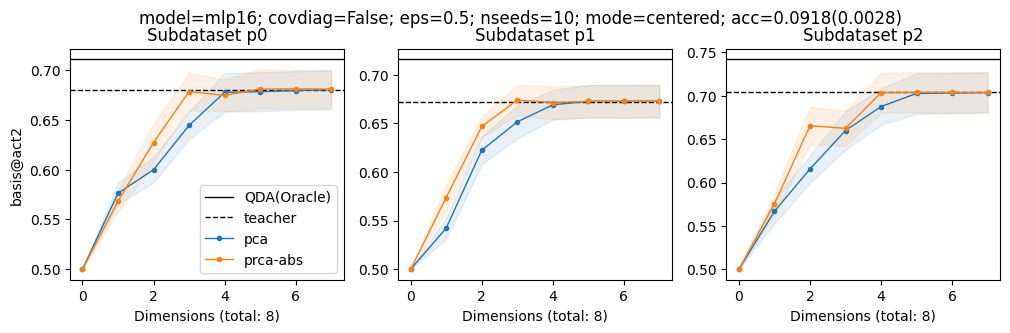

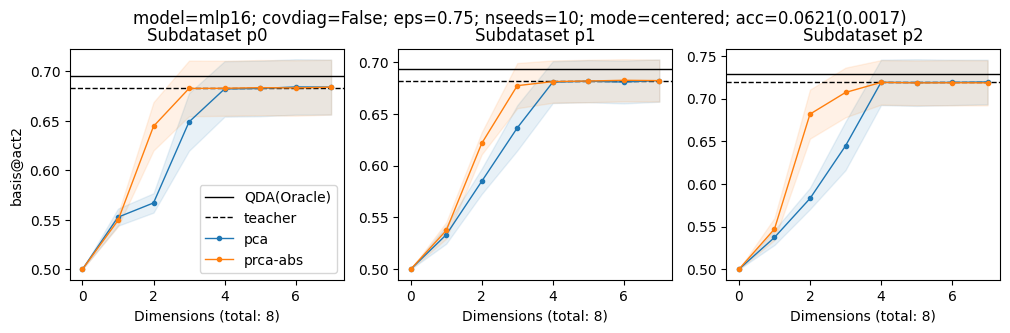

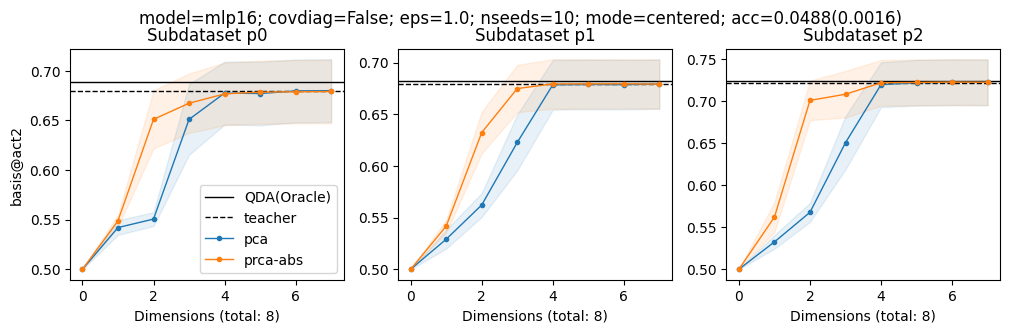

In [6]:
def ano():
    
    for eps in [0.5, 0.75, 1.0]:
        viz_auroc(eps=eps, covdiag=False, layers=["act2"])
ano()

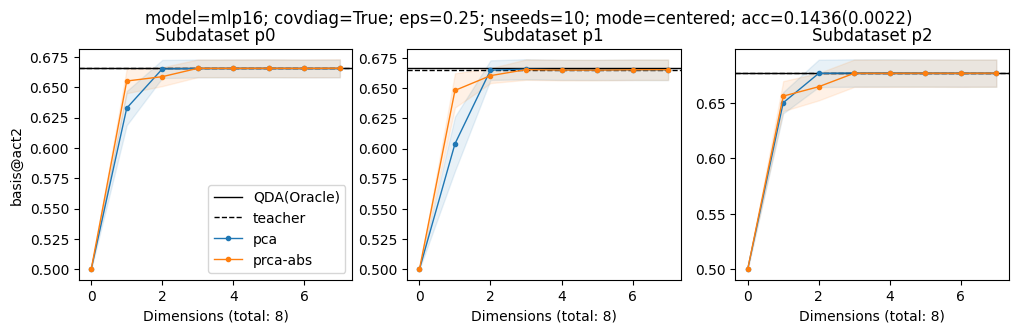

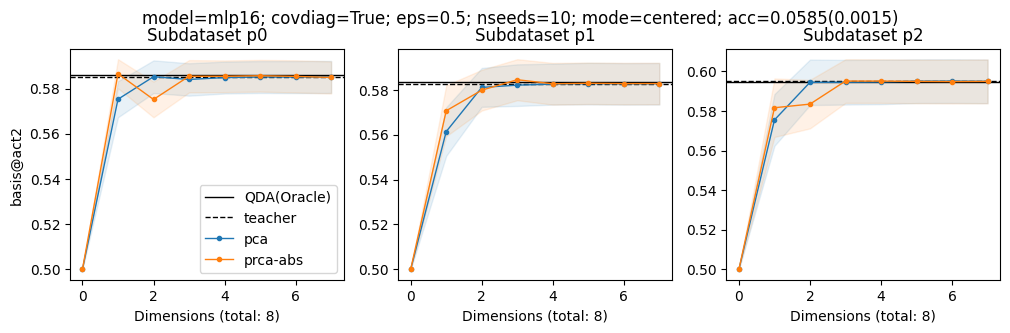

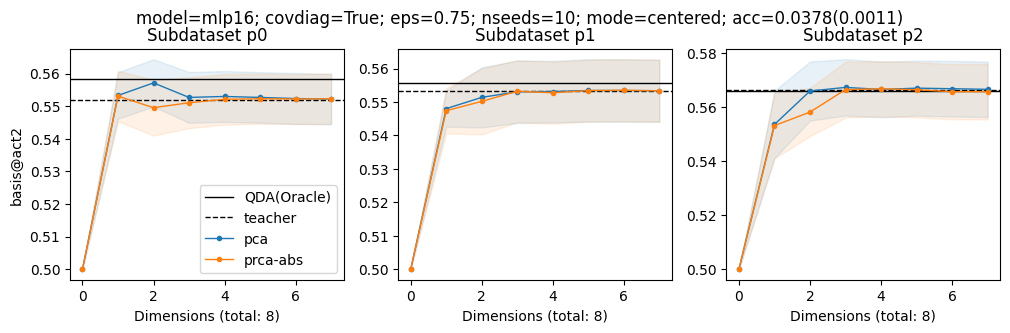

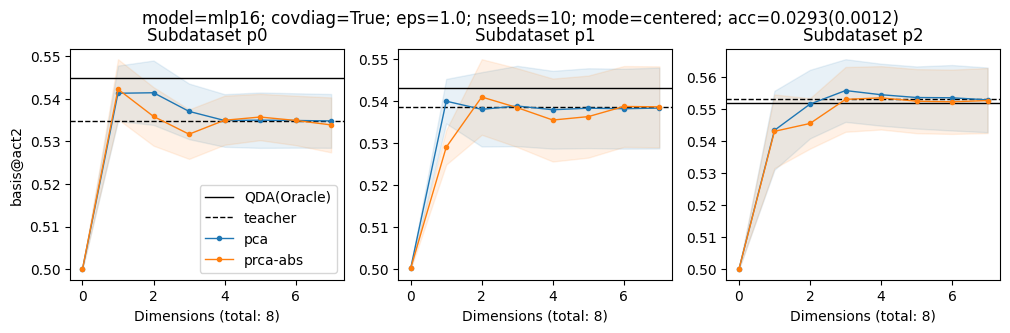

In [7]:
def ano():
    
    for eps in [0.25, 0.5, 0.75, 1.0]:
        viz_auroc(eps=eps, covdiag=True, layers=["act2"])
ano()

# Compare Across Basis

In [ ]:
def ano():
    for eps in [0.5, 0.75, 1.0]:
        viz_auroc(
            eps=eps,
            covdiag=False,
            layers=["act2"],
            basis_names = [
                "pca", 
                "prca-abs",
                "rel", "rel-abs",
            ]
        )
ano()